In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from bayes_opt import BayesianOptimization
from sm import NeuralNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [15]:
def normalize_over_range(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

def forward_whole_range(model, param_list, input_idx, v_min, v_max, N):

    in_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

    c_volt = torch.tensor(param_list, dtype=torch.float32).expand(N, -1)
    c_volt_l = c_volt[:, :input_idx]
    c_volt_r = c_volt[:, input_idx:]

    input_tensor = torch.cat([c_volt_l, in_range, c_volt_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().numpy()

    return y_out

def target_function(x):

    m = nn.ReLU()
        
    return m(x)

def mse_loss(x, y):

    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse    

v_min = -1.5
v_max = 1.5

N = 500
input_range = torch.linspace(v_min, v_max, N).unsqueeze(1)

d = 6
pbounds = {
    f'x{i}': (v_min, v_max) for i in range(d) 
}

input_idx = 3
target = target_function(input_range)

def f(**kwargs):

    cv_list = list(kwargs.values())
    cv_t = torch.tensor(cv_list, dtype=torch.float32).expand(N, -1)
    cv_t_l = cv_t[:, :input_idx]
    cv_t_r = cv_t[:, input_idx:]

    input_tensor = torch.cat([cv_t_l, input_range, cv_t_r], dim=1)

    model.eval()
    with torch.no_grad():
        y_out = model(input_tensor)

    loss = mse_loss(y_out, target)

    return -loss

In [16]:
state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_n_a=200.pth", weights_only=False, map_location='cpu')
print(state_dict['args'])
model = NeuralNet(
    state_dict['args']['layer_dims'],
    state_dict['args']['x_mean'],
    state_dict['args']['x_std'],
    state_dict['args']['y_mean'],
    state_dict['args']['y_std']
)
model.load_state_dict(state_dict['model_state_dict'])

optimizer = BayesianOptimization(
    f=f,
    pbounds=pbounds,
    verbose=1,
    random_state=np.random.randint(0, 2**31 - 1),
)
optimizer.maximize(
    init_points=10,
    n_iter=150,
)

{'data_dir': PosixPath('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB_own_pde_solver'), 'num_batches': 180, 'batch_size': 512, 'x_mean': array([-8.01042443e-05, -4.84397956e-05,  1.27591542e-04, -1.36573186e-03,
        1.29713429e-03,  9.82766649e-04, -6.81038087e-04]), 'x_std': array([0.86585553, 0.86589274, 0.86606062, 0.865617  , 0.86568139,
       0.86553458, 0.86612566]), 'y_mean': np.float64(-0.03779365664983197), 'y_std': np.float64(0.14455336756115278), 'layer_dims': [7, 128, 128, 128, 1], 'num_epochs': 500, 'lr': 0.001, 'save_name': PosixPath('/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_n_a=200')}
|   iter    |  target   |    x0     |    x1     |    x2     |    x3     |    x4     |    x5     |
-------------------------------------------------------------------------------------------------
| 2         | -0.278655 | -1.445367 | 1.2922787 | 0.1017121 | -0.920670 | 1.1435803 | 0.1387041 |
| 3         | -0.144718 | 1.2386670 | -0.309844 | 1.3477482 | 0.8118590 | 1.3781049 |

[-1.5, 1.5, 1.5, 0.0038004407013444313, 1.5, 1.5]


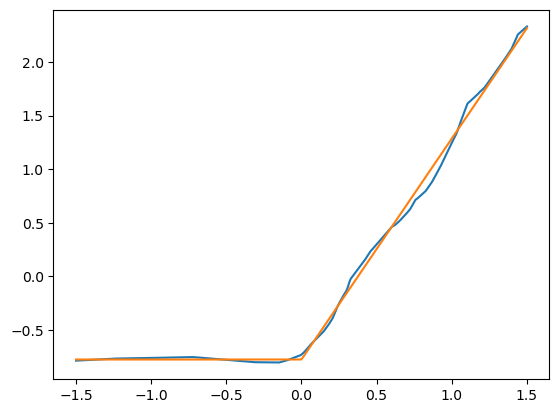

In [17]:
opt_vals = list(optimizer.max['params'].values())
print(np.array(opt_vals).tolist())

y_out = forward_whole_range(model, opt_vals, input_idx, v_min, v_max, N)

y_sc = normalize_over_range(y_out)
t_sc = normalize_over_range(target)

data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/relu/sim_relu.npz")
I_sc = normalize_over_range(data['current'])

#plt.plot(np.linspace(v_min, v_max, 50), I_sc, label='simulation')
plt.plot(input_range, y_sc, label='sm')
plt.plot(input_range, t_sc, label='target')

In [ ]:
num_runs = 200

opt_param_list = []
for i in range(num_runs):
    optimizer = BayesianOptimization(
        f=f,
        pbounds=pbounds,
        verbose=0,
        random_state=i,
    )
    optimizer.maximize(
        init_points=10,
        n_iter=100,
    )
    opt_param_list.append(np.array(list(optimizer.max['params'].values())).tolist())
    if i % 10 == 0:
        print(f'{i+1}/{num_runs} | Params: {opt_param_list[i]}')

opt_param_arr = np.stack(opt_param_list)
np.save('opt_param_arr_relu', opt_param_arr)

In [ ]:
print(opt_param_list[1])


fig, ax = plt.subplots(ncols=d, figsize=(3*d, 3))

for a in ax:
    a.set_box_aspect(1)

for i in range(d):
    ax[i].hist(opt_param_arr[:, i], bins=10, alpha=.75)